In [ ]:
!pip install transformers
!pip install torch
!pip install scikit-learn
!pip install gradio
!pip install nltk

In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], axis=0)
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Corinthian Colleges Must Pay Students More Th...,Corinthian Colleges must pay $1.2 billion doll...,News,"March 26, 2016",0
1,TERRIFIC! PRESIDENT TRUMP Takes On The United ...,THE US PROVIDES 22% OF THE BUDGET FOR THE UNIT...,Government News,"Jan 26, 2017",0
2,"WATCH: Conservatives Don’t Punch Nazis, They ...",If there is one political ideology that every ...,News,"February 23, 2017",0
3,Cholera claims unborn children as epidemic spr...,"HODEIDAH, Yemen (Reuters) - One of the latest ...",worldnews,"October 9, 2017",1
4,Catalans occupy voting stations to defy Madrid...,BARCELONA (Reuters) - Supporters of Catalan in...,worldnews,"September 29, 2017",1


In [ ]:
df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]
df.head()

,content,label
0,Corinthian Colleges Must Pay Students More Th...,0
1,TERRIFIC! PRESIDENT TRUMP Takes On The United ...,0
2,"WATCH: Conservatives Don’t Punch Nazis, They ...",0
3,Cholera claims unborn children as epidemic spr...,1
4,Catalans occupy voting stations to defy Madrid...,1


In [ ]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


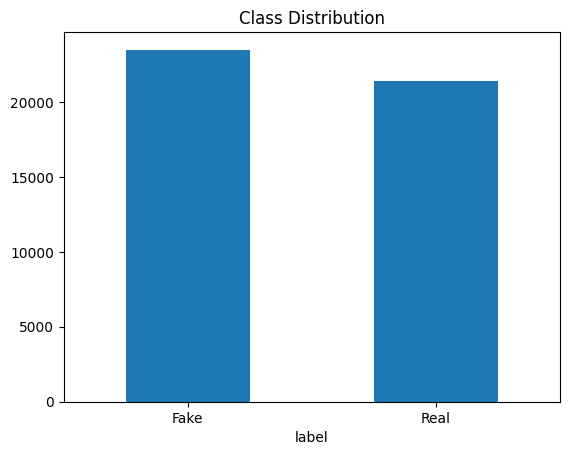

In [ ]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xticks([0,1], ["Fake", "Real"], rotation=0)
plt.show()

In [ ]:
import nltk
import re

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["content"] = df["content"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_model.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:04:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate(model, X_test, y_test):

    pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, pred))

evaluate(svm_model, X_test_tfidf, y_test)
evaluate(rf_model, X_test_tfidf, y_test)
evaluate(xgb_model, X_test_tfidf, y_test)

Accuracy: 0.994543429844098
Accuracy: 0.9974387527839643
Accuracy: 0.9979955456570155


In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertModel.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import numpy as np

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


def get_embeddings(text_list, batch_size=32):

    embeddings = []

    for i in range(0, len(text_list), batch_size):

        batch = text_list[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=256,   # faster than 512 and still accurate
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():

            outputs = model(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(embeddings)

In [ ]:
X_train_emb = get_embeddings(X_train.tolist())
X_test_emb = get_embeddings(X_test.tolist())

In [ ]:
svm_hybrid = LinearSVC()
svm_hybrid.fit(X_train_emb, y_train[:len(X_train_emb)])

LinearSVC()

In [ ]:
rf_hybrid = RandomForestClassifier()

rf_hybrid.fit(X_train_emb, y_train[:len(X_train_emb)])

RandomForestClassifier()

In [ ]:
xgb_hybrid = XGBClassifier()

xgb_hybrid.fit(X_train_emb, y_train[:len(X_train_emb)])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time


def evaluate_model(model, X_test, y_test, model_name):

    print(f"\n===== {model_name} Evaluation =====")

    # Inference latency
    start = time.time()
    predictions = model.predict(X_test)
    end = time.time()

    latency = end - start

    # Accuracy + Precision + Recall + F1
    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")

    plt.show()

    # Latency output
    print(f"Inference Latency: {latency:.6f} seconds")


===== DistilBERT + SVM Hybrid Model Evaluation =====

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4688
           1       0.98      0.98      0.98      4292

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



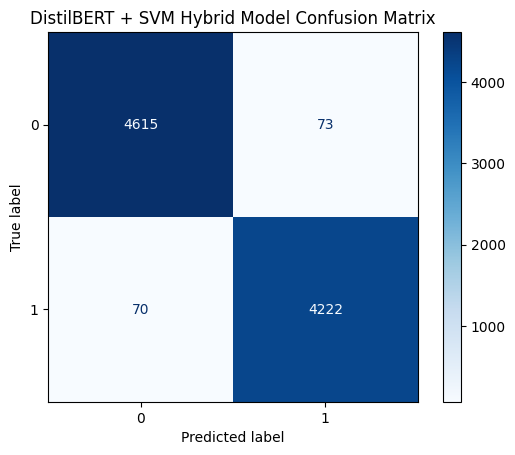

Inference Latency: 0.023553 seconds

===== DistilBERT + Random Forest Hybrid Model Evaluation =====

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4688
           1       0.95      0.95      0.95      4292

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



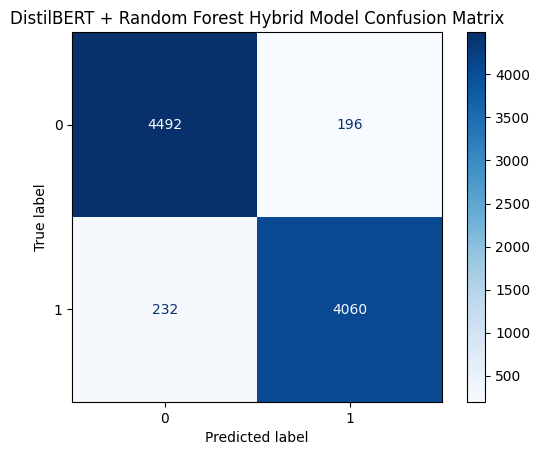

Inference Latency: 0.167258 seconds

===== DistilBERT + XGBoost Hybrid Model Evaluation =====

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4688
           1       0.97      0.97      0.97      4292

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



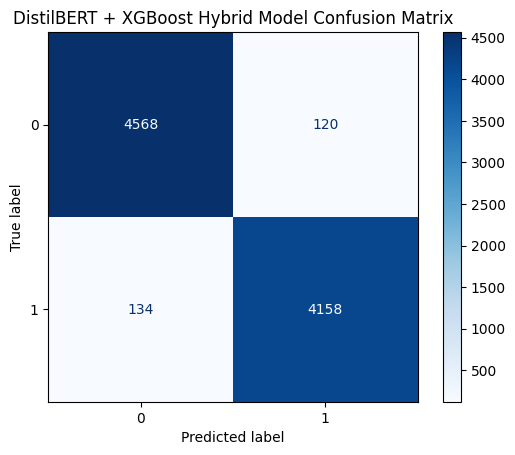

Inference Latency: 0.036494 seconds


In [ ]:
evaluate_model(
    svm_hybrid,
    X_test_emb,
    y_test[:len(X_test_emb)],
    "DistilBERT + SVM Hybrid Model"
)

evaluate_model(
    rf_hybrid,
    X_test_emb,
    y_test[:len(X_test_emb)],
    "DistilBERT + Random Forest Hybrid Model"
)

evaluate_model(
    xgb_hybrid,
    X_test_emb,
    y_test[:len(X_test_emb)],
    "DistilBERT + XGBoost Hybrid Model"
)

In [ ]:
import pickle

pickle.dump(svm_hybrid, open("best_model.pkl","wb"))
pickle.dump(tfidf, open("tfidf.pkl","wb"))

In [ ]:
import gradio as gr

In [ ]:
def predict_news(text):

    cleaned_text = clean_text(text)

    embedding = get_embeddings([cleaned_text])

    prediction = svm_hybrid.predict(embedding)[0]

    # confidence score (approximate)
    confidence = np.max(svm_hybrid.decision_function(embedding))

    if prediction == 1:

        result = " REAL NEWS"

    else:

        result = " FAKE NEWS"

    return result, f"Confidence Score: {confidence:.2f}"


with gr.Blocks(theme=gr.themes.Soft()) as interface:

    gr.Markdown(
        """
        # Hybrid AI Fake News Detection System
        ### DistilBERT + Machine Learning Model

        Paste any news article text below to check whether it is **Real or Fake**.
        """
    )

    with gr.Row():

        with gr.Column():

            news_input = gr.Textbox(
                label="Enter News Article Text",
                placeholder="Paste news content here...",
                lines=10
            )

            check_button = gr.Button(" Detect News Authenticity")

        with gr.Column():

            prediction_output = gr.Textbox(label="Prediction Result")

            confidence_output = gr.Textbox(label="Model Confidence")


    check_button.click(
        fn=predict_news,
        inputs=news_input,
        outputs=[prediction_output, confidence_output]
    )


    gr.Markdown(
        """
        ---
        Model Architecture:
        - DistilBERT contextual embeddings
        - Hybrid classifier
        - TF-IDF linguistic features

        Developed for academic research deployment demonstration
        """
    )


interface.launch()

/tmp/ipykernel_1540/2992462821.py:23: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as interface:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b948bc1c4de3d31cbd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
